# Sampling, Aliasing, Quantization & ADC

Exploring how analog signals are converted into digital samples and how sampling and quantization affect the signal.

## Objective

In this notebook, we will:

- Understand sampling and sampling frequency
- Explore the Nyquist theorem
- Observe aliasing
- Understand quantization
- Connect sampling and quantization to the basic operation of an ADC

## Theory

### Sampling

Sampling converts a continuous-time signal into discrete-time samples.

The sampling frequency is:

$$
f_s = \frac{1}{T_s}
$$

where $T_s$ is the sampling period.

### Nyquist Theorem

To represent a band-limited signal without aliasing:

$$
f_s > 2f_{max}
$$

where $f_{max}$ is the highest frequency component of the signal.

### Aliasing

When the sampling frequency is too low, different continuous-time frequencies can produce the same sampled data. This effect is called aliasing.

### Quantization

Quantization maps continuous amplitude values to a finite number of discrete levels.

### ADC

A simplified ADC process can be viewed as:

$$
\text{Analog Signal}
\rightarrow
\text{Sampling}
\rightarrow
\text{Quantization}
\rightarrow
\text{Digital Output}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f_signal = 100
duration = 0.05

fs_high = 5000

t = np.arange(0, duration, 1/fs_high)

signal = np.sin(2 * np.pi * f_signal * t)

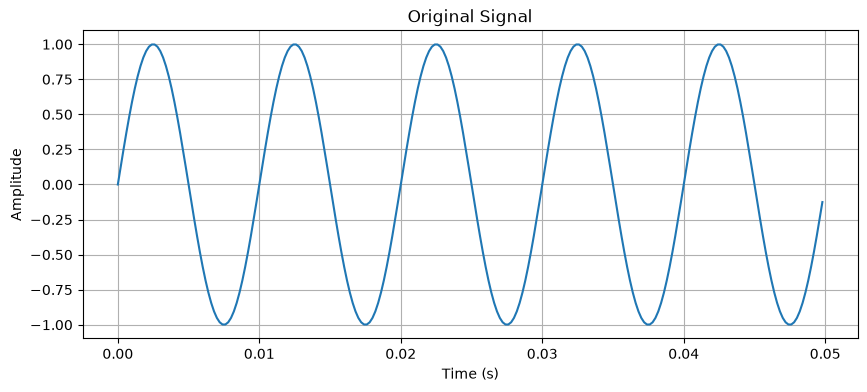

In [3]:
plt.figure(figsize=(10, 4))

plt.plot(t, signal)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original Signal")
plt.grid(True)

plt.show()

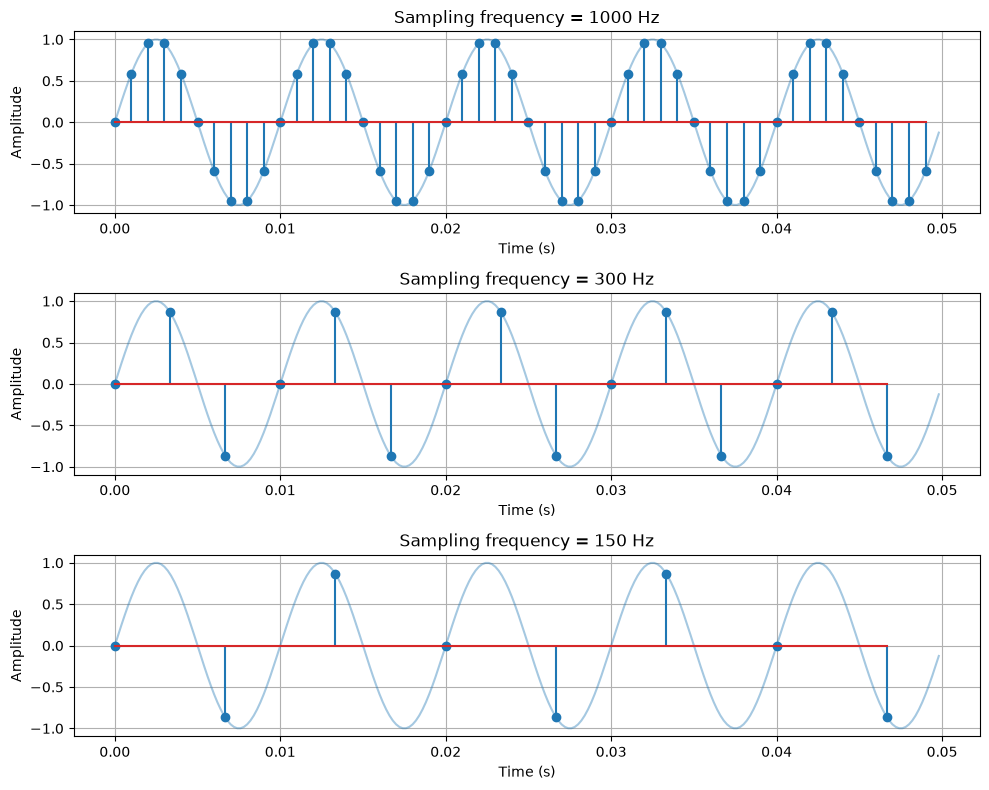

In [4]:
fs_values = [1000, 300, 150]

plt.figure(figsize=(10, 8))

for i, fs in enumerate(fs_values, 1):

    t_sampled = np.arange(0, duration, 1/fs)
    x_sampled = np.sin(2 * np.pi * f_signal * t_sampled)

    plt.subplot(3, 1, i)

    plt.plot(t, signal, alpha=0.4)
    plt.stem(t_sampled, x_sampled)

    plt.title(f"Sampling frequency = {fs} Hz")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Observations

- As sampling frequency increases, sample number for the signal grows and representing the signal gets easier.

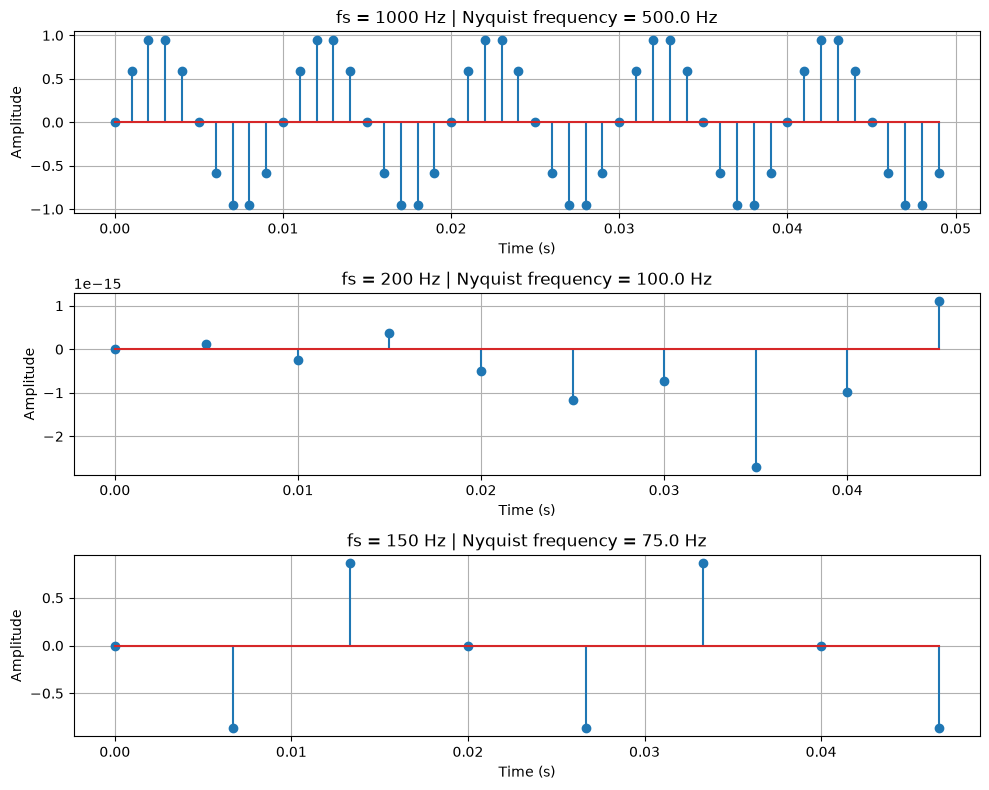

In [5]:
fs_values = [1000, 200, 150]

plt.figure(figsize=(10, 8))

for i, fs in enumerate(fs_values, 1):

    t_sampled = np.arange(0, duration, 1/fs)
    x_sampled = np.sin(2 * np.pi * f_signal * t_sampled)

    plt.subplot(3, 1, i)

    plt.stem(t_sampled, x_sampled)

    plt.title(
        f"fs = {fs} Hz | Nyquist frequency = {fs/2:.1f} Hz"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Observations

- For 100Hz signal, nquyist frequency of 500Hz easily represents the signal.
- At exact 100Hz nquyist frequency, plot starts to distort.
- At 75Hz, plot significantly gets distorted.

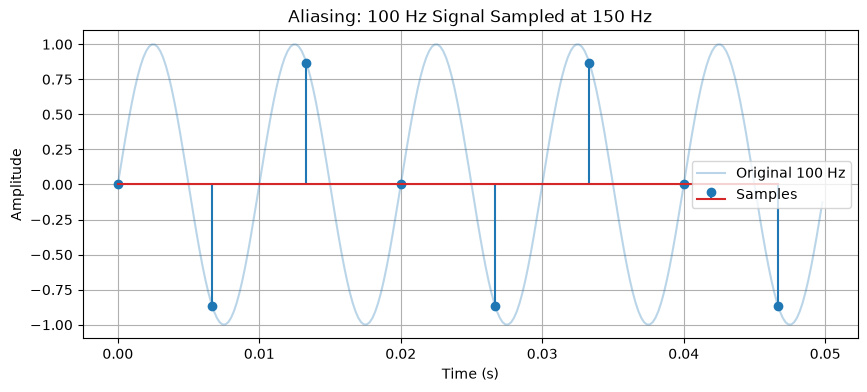

In [6]:
fs = 150

t_sampled = np.arange(0, duration, 1/fs)

sampled_signal = np.sin(2 * np.pi * f_signal * t_sampled)

plt.figure(figsize=(10, 4))

plt.plot(t, signal, alpha=0.3, label="Original 100 Hz")
plt.stem(t_sampled, sampled_signal, label="Samples")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Aliasing: 100 Hz Signal Sampled at 150 Hz")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
alias_frequency = abs(fs - f_signal)

print(f"Original frequency: {f_signal} Hz")
print(f"Sampling frequency: {fs} Hz")
print(f"Observed alias frequency: {alias_frequency} Hz")

Original frequency: 100 Hz
Sampling frequency: 150 Hz
Observed alias frequency: 50 Hz


## Observations

- At 100Hz sampling, nquyist freq. becomes 75Hz.
- Signal gets distorted and acts like a 50Hz signal.

In [8]:
bits = 3
levels = 2**bits

x = np.linspace(-1, 1, 1000)

In [9]:
quantized = np.round(
    (x + 1) / 2 * (levels - 1)
)

quantized = (
    quantized / (levels - 1)
) * 2 - 1

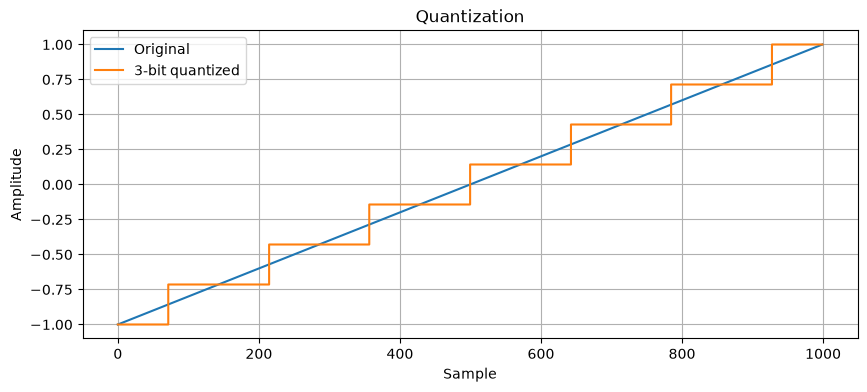

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(x, label="Original")
plt.step(
    np.arange(len(x)),
    quantized,
    where="mid",
    label=f"{bits}-bit quantized"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Quantization")
plt.legend()
plt.grid(True)

plt.show()

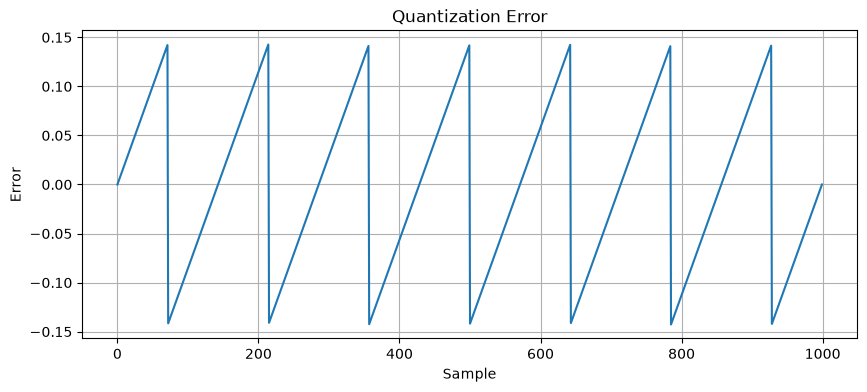

In [11]:
error = x - quantized

plt.figure(figsize=(10, 4))

plt.plot(error)

plt.xlabel("Sample")
plt.ylabel("Error")
plt.title("Quantization Error")
plt.grid(True)

plt.show()

## Observations

- As sampling increases, amplitude of original signal continuously increases but quantized signal increases at discrete levels.
- Quantization rounds the sensitive spikes to certain discrete levels.
- Quantization error shows data losses during the quantization. It increases continuously but suddenly drops at some sample points.
- The drop points correlate to ladder spikes at the sample vs amplitude plot.

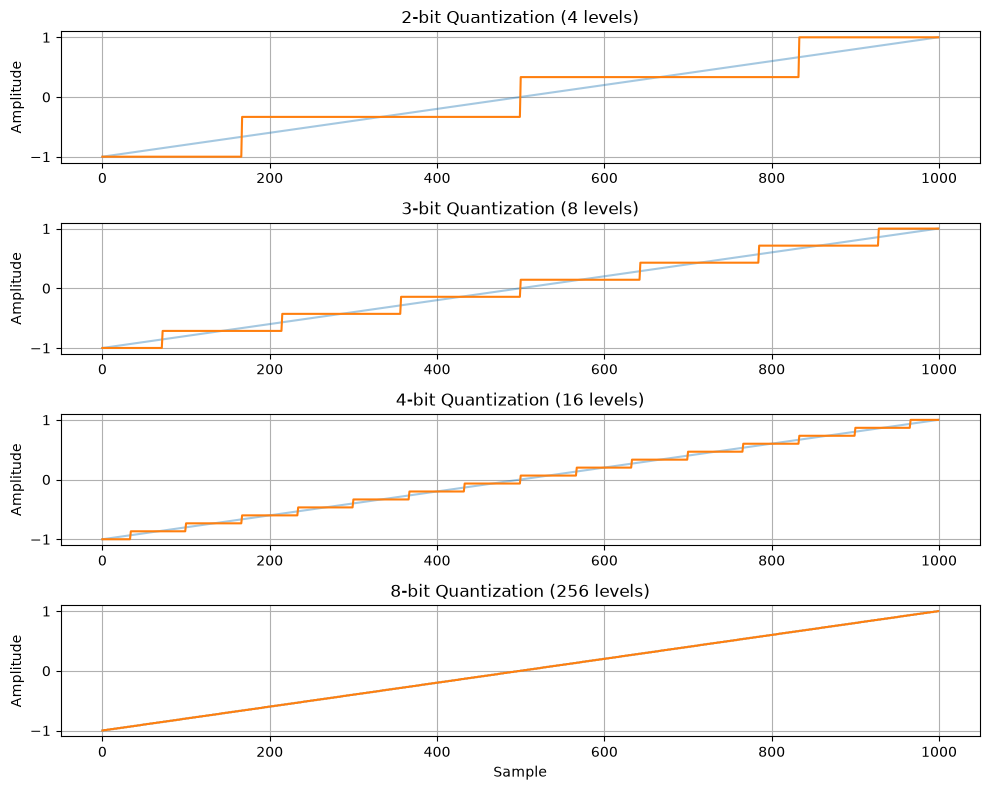

In [12]:
bit_values = [2, 3, 4, 8]

plt.figure(figsize=(10, 8))

for i, bits in enumerate(bit_values, 1):

    levels = 2**bits

    quantized = np.round(
        (x + 1) / 2 * (levels - 1)
    )

    quantized = (
        quantized / (levels - 1)
    ) * 2 - 1

    plt.subplot(4, 1, i)

    plt.plot(x, alpha=0.4)
    plt.plot(quantized)

    plt.title(f"{bits}-bit Quantization ({levels} levels)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.xlabel("Sample")
plt.tight_layout()
plt.show()

## Observations

- As bit number increases, the resolution becomes more accurate, quantized signal gets closer to the original cont. signal and data loss decreases.

In [13]:
f_signal = 100
fs = 500

duration = 0.05

t_continuous = np.linspace(0, duration, 5000)
analog_signal = np.sin(2 * np.pi * f_signal * t_continuous)

In [14]:
t_sampled = np.arange(0, duration, 1/fs)
sampled_signal = np.sin(2 * np.pi * f_signal * t_sampled)

In [15]:
bits = 3
levels = 2**bits

quantized_signal = np.round(
    (sampled_signal + 1) / 2 * (levels - 1)
)

quantized_signal = (
    quantized_signal / (levels - 1)
) * 2 - 1

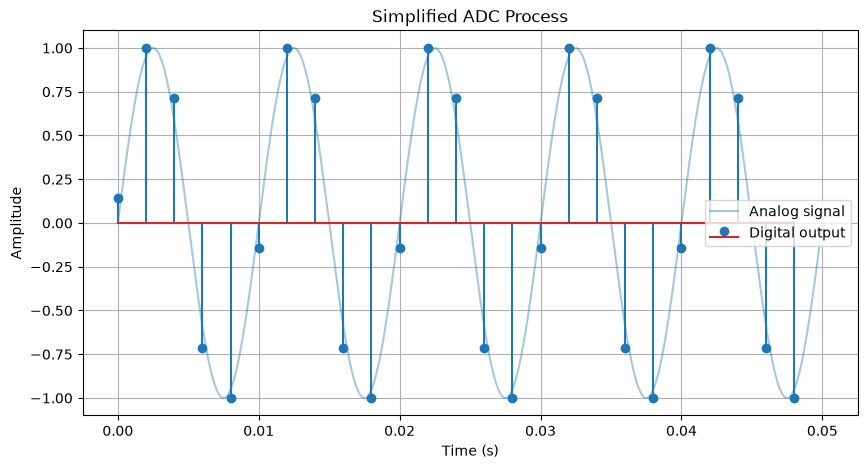

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    t_continuous,
    analog_signal,
    alpha=0.4,
    label="Analog signal"
)

plt.stem(
    t_sampled,
    quantized_signal,
    label="Digital output"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simplified ADC Process")
plt.legend()
plt.grid(True)

plt.show()

## Observations

- The complete ADC chain gets simulated by first sampling the analog signal,
- Then quantizing for 3 bits (9 levels),
- Finally plotting the analog and digitalized signals.

## Key Takeaways

- Sampling discretizes time axis at time vs amplitude graph.
- Quantization discretizes amplitude axis at the same graph.
- Nquyist freq. value should be big enough so that we can avoid aliasing and errors the aliasing comes with.
- Sampling freq. and quantization bit depth is directly proportional to time and amplitude resolution, respectively.
- ADC discretizes an analog signal by sampling and then quantizing the analog input and produces a digital output.

## Next Step

Next, we will explore complex exponentials, Euler's formula, phasors, and the mathematical foundation of I/Q signals.